##**Reading file**


This cell imports the pandas library, reads the 'Sample - Superstore.csv' file into a DataFrame `df`, specifying 'Order Date' as a date column and 'latin1' encoding to handle potential decoding errors. Finally, it displays the first 5 rows of the DataFrame to quickly inspect the data.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Sample - Superstore.csv", parse_dates=["Order Date"], encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


###  Data Cleaning and Sorting
This cell first checks for any missing values in the DataFrame. It then drops any rows with missing values (`dropna()`) to ensure data quality. Finally, it sorts the entire DataFrame by the 'Order Date' column, which is crucial for time-series analysis.

In [ ]:
# Check missing values
df.isnull().sum()

# Drop or fill
df = df.dropna()

# Sort by date
df = df.sort_values("Order Date")

###  Feature Engineering and Monthly Aggregation
This cell extracts time-based features (`year`, `month`, `day`, `day_of_week`) from the 'Order Date' column. It then aggregates the data to calculate the total 'Sales' for each month, storing the result in `monthly_sales`. The `resample('ME')` function is used for monthly aggregation at month-end.

In [ ]:
df["year"] = df["Order Date"].dt.year
df["month"] = df["Order Date"].dt.month
df["day"] = df["Order Date"].dt.day
df["day_of_week"] = df["Order Date"].dt.dayofweek

# Monthly aggregation
monthly_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
monthly_sales = monthly_sales.set_index("Order Date").resample("ME").sum()

###  Monthly Sales Trend Visualization
This cell uses `matplotlib.pyplot` to create and display a line plot of the `monthly_sales` data. The plot visualizes the overall trend of sales over time, allowing for an easy understanding of historical sales patterns.

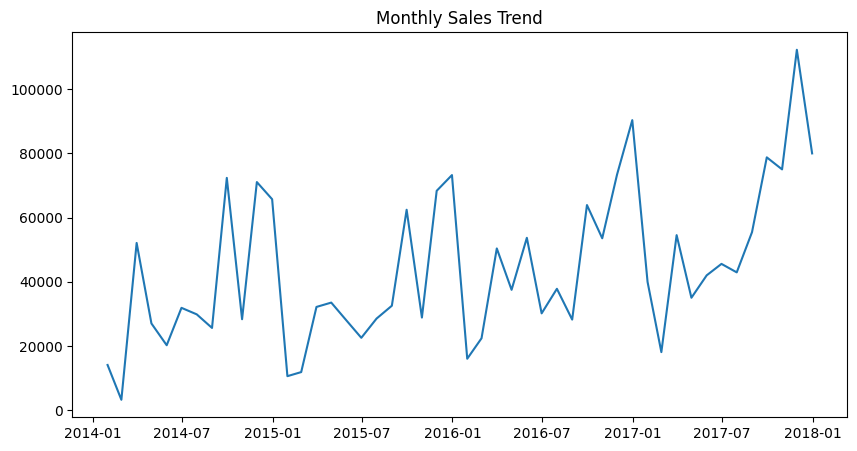

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales["Sales"])
plt.title("Monthly Sales Trend")
plt.show()

### Linear Regression Model Training
This cell prepares the data for a linear regression model. It adds a `time_index` column to `monthly_sales`. It then splits the data into training and testing sets using `train_test_split`. A `LinearRegression` model is initialized and trained on the training data (`X_train`, `y_train`) to learn the relationship between `time_index` and `Sales`. Finally, it generates predictions on the test set (`X_test`).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

monthly_sales["time_index"] = range(len(monthly_sales))

X = monthly_sales[["time_index"]]
y = monthly_sales["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

###  Future Sales Prediction
This cell forecasts future sales using the trained linear regression model. It defines `future_steps` (6 months) and creates a `future_index` for these steps. It then uses the `model.predict()` method with this `future_index` to get `future_preds` (predicted sales for the next 6 months).

In [ ]:
future_steps = 6
future_index = range(len(monthly_sales), len(monthly_sales)+future_steps)

future_preds = model.predict(pd.DataFrame({"time_index": future_index}))

###  Actual vs. Predicted Sales Visualization
This cell visualizes the actual monthly sales against the predicted sales from the linear regression model. It uses `matplotlib.pyplot` to plot the `monthly_sales` (actual), `predictions` (from the test set), and `future_preds` (future forecasts) on the same graph, allowing for a comprehensive comparison of the model's performance and future outlook.

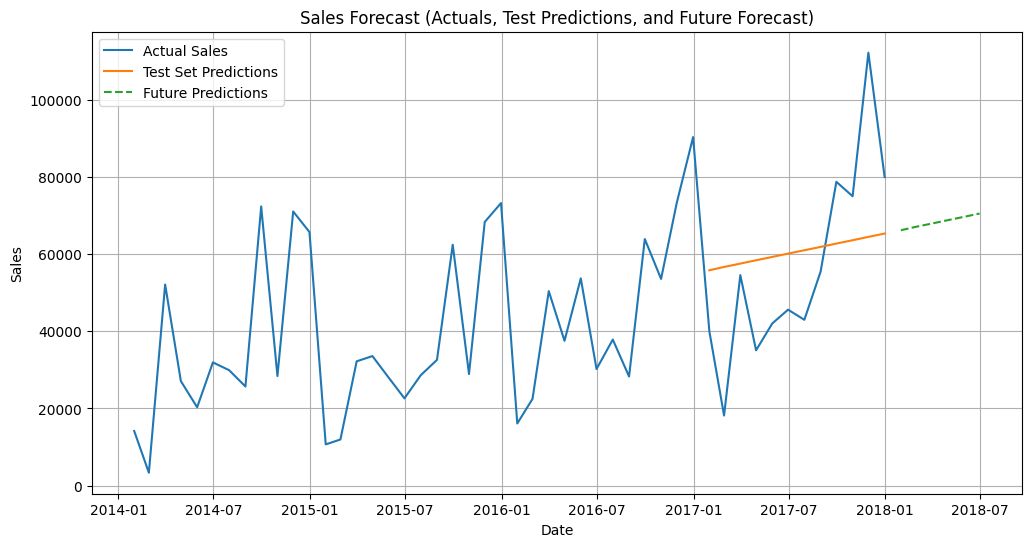

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales["Sales"], label="Actual Sales")
plt.plot(monthly_sales.index[-len(predictions):], predictions, label="Test Set Predictions")

# Create a date index for future predictions
last_date = monthly_sales.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_steps+1, freq='ME')[1:] # Exclude the last actual month

plt.plot(future_dates, future_preds, label="Future Predictions", linestyle='--')

plt.legend()
plt.title("Sales Forecast (Actuals, Test Predictions, and Future Forecast)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()